# 🎬 IMDB Sentiment Analysis 


---



## 📦 Section 1 — Import Libraries


In [1]:
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print('✅ All libraries imported successfully')


✅ All libraries imported successfully


## 📂 Section 2 — Load Dataset

**Download from Kaggle:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)


In [2]:
CSV_PATH = "IMDB Dataset.csv"   
df = pd.read_csv("C:\\Users\\Habiba Elboraii\\Downloads\\archive (2)\\IMDB Dataset.csv")


In [3]:
df.columns = df.columns.str.lower().str.strip()
df = df[["review", "sentiment"]].dropna()
df["sentiment"] = df["sentiment"].str.lower().str.strip()
df["label"] = (df["sentiment"] == "positive").astype(int)  

In [4]:
print(f"Total reviews  : {len(df):,}")
print(f"Positive       : {df['label'].sum():,}")
print(f"Negative       : {(df['label']==0).sum():,}")

Total reviews  : 50,000
Positive       : 25,000
Negative       : 25,000


In [5]:
df.head(5)

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


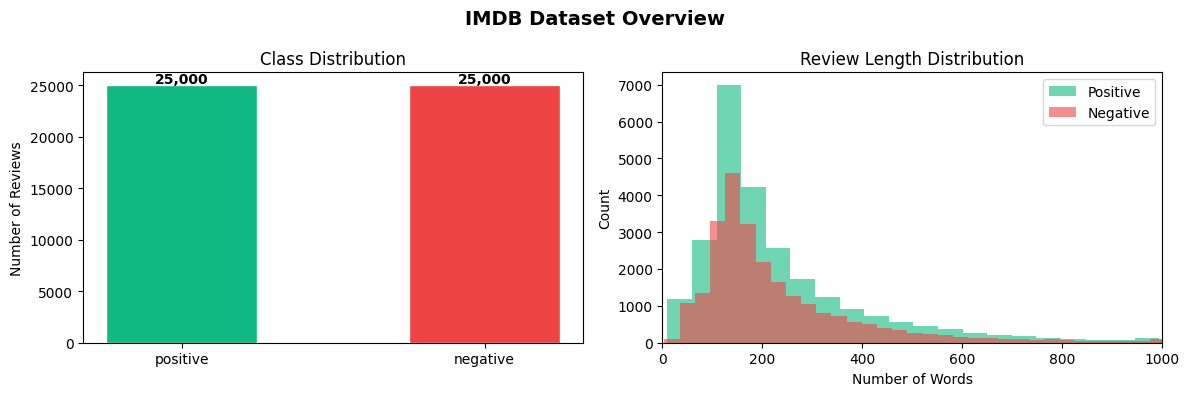


Average review length: 231 words


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("IMDB Dataset Overview", fontsize=14, fontweight="bold")

# Bar chart
counts = df["sentiment"].value_counts()
colors = ["#10B981", "#EF4444"]
axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

# Review length distribution
df["review_len"] = df["review"].str.split().str.len()
axes[1].hist(df[df["label"]==1]["review_len"], bins=50, alpha=0.6,
             color="#10B981", label="Positive")
axes[1].hist(df[df["label"]==0]["review_len"], bins=50, alpha=0.6,
             color="#EF4444", label="Negative")
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()
print(f"\nAverage review length: {df['review_len'].mean():.0f} words")

## 🔧 Section 3 — NLP Preprocessing Pipeline

### Pipeline Steps:
| # | Step | Purpose |
|---|------|---------|
| 1 | HTML cleaning | Remove `<br />`, `&amp;`, etc. |
| 2 | URL removal | Remove http links |
| 3 | Lowercase | Normalize text |
| 4 | Contraction expansion | `won't` → `will not` |
| 5 | Tokenization | Split into words |
| 6 | **Negation tagging** ⭐ | `not good` → `not_good` |
| 7 | Stop word removal | Remove low-value words (NOT negations) |
| 8 | Short token removal | Remove len < 2 tokens |


In [7]:
# ── Negation words — NEVER remove these ──────────────────
NEGATION_WORDS = {
    "not", "no", "never", "neither", "nobody", "nothing",
    "nowhere", "nor", "hardly", "scarcely", "barely",
    "will not", "do not", "did not", "is not", "are not",
    "was not", "were not", "have not", "has not", "had not",
}

# ── Safe stop words — negations are EXCLUDED ──────────────
SAFE_STOP_WORDS = {
    "i","me","my","myself","we","our","ours","ourselves",
    "you","your","yours","yourself","he","him","his","himself",
    "she","her","hers","herself","it","its","itself",
    "they","them","their","theirs","themselves",
    "what","which","who","whom","this","that","these","those",
    "am","is","are","was","were","be","been","being",
    "have","has","had","having","do","does","did","doing",
    "a","an","the","and","but","if","or","because","as",
    "until","while","of","at","by","for","with","about",
    "against","between","into","through","during","before",
    "after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","further",
    "then","once","here","there","when","where","why","how",
    "all","both","each","few","more","most","other","some",
    "such","so","than","too","very","s","t","will","just",
    "now","d","ll","m","o","re","ve","y",
} - NEGATION_WORDS  # safety: remove any negations that slipped in

# ── Contraction map ───────────────────────────────────────
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "it's": "it is", "that's": "that is",
    "there's": "there is", "they're": "they are",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "wouldn't": "would not", "shouldn't": "should not",
    "couldn't": "could not", "mustn't": "must not",
}

print("✅ Preprocessing constants defined")
print(f"   Stop words  : {len(SAFE_STOP_WORDS)}")
print(f"   Negations   : {len(NEGATION_WORDS)}")
print(f"   Contractions: {len(CONTRACTIONS)}")

✅ Preprocessing constants defined
   Stop words  : 123
   Negations   : 21
   Contractions: 33


In [8]:
def clean_html(text: str) -> str:
    # Decode HTML entities
    text = text.replace("&amp;", "&").replace("&lt;", "<")
    text = text.replace("&gt;", ">").replace("&quot;", '"')
    text = text.replace("&#39;", "'").replace("&nbsp;", " ")
    text = text.replace("<br />", " ").replace("<br>", " ")
    # Strip remaining HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return text


def expand_contractions(text: str) -> str:
    for c, expansion in CONTRACTIONS.items():
        text = text.replace(c, expansion)
    return text


def handle_negation(tokens: list) -> list:
    result = []
    negate_count = 0
    negate_prefix = "not"

    for token in tokens:
        if token in NEGATION_WORDS:
            result.append(token)
            negate_count = 3          # affect next 3 tokens
            negate_prefix = token
        elif negate_count > 0:
            result.append(negate_prefix + "_" + token)
            negate_count -= 1
            # Reset at sentence boundaries
            if token in {".", "!", "?", ";"}:
                negate_count = 0
        else:
            result.append(token)
    return result


def preprocess(text: str) -> str:
    text = clean_html(text)                          # Step 1
    text = text.lower()                              # Step 2
    text = expand_contractions(text)                 # Step 3
    tokens = re.findall(r"\b[a-z][a-z']*\b", text)  # Step 4
    tokens = handle_negation(tokens)                 # Step 5
    tokens = [t for t in tokens
              if t not in SAFE_STOP_WORDS]           # Step 6
    tokens = [t for t in tokens if len(t) >= 2]     # Step 7
    return " ".join(tokens)


print("✅ Preprocessing functions defined")

✅ Preprocessing functions defined


In [9]:
# ── Demo: show preprocessing step-by-step ────────────────
demo_texts = [
    "This movie was not good at all. I didn't enjoy it.",
    "I can't believe how amazing this film is! Absolutely loved it.",
    "The acting was never boring and the plot was never predictable.",
]

print("=" * 65)
print("PREPROCESSING DEMO — negation handling")
print("=" * 65)

for text in demo_texts:
    result = preprocess(text)
    print(f"\n  ORIGINAL  : {text}")
    print(f"  PROCESSED : {result}")
    negated = [t for t in result.split() if t.startswith("not_")]
    if negated:
        print(f"  NEGATED   : {negated}  ← polarity preserved!")
print("\n" + "=" * 65)

PREPROCESSING DEMO — negation handling

  ORIGINAL  : This movie was not good at all. I didn't enjoy it.
  PROCESSED : movie not not_good not_at not_all not not_enjoy not_it
  NEGATED   : ['not_good', 'not_at', 'not_all', 'not_enjoy', 'not_it']  ← polarity preserved!

  ORIGINAL  : I can't believe how amazing this film is! Absolutely loved it.
  PROCESSED : cannot believe amazing film absolutely loved

  ORIGINAL  : The acting was never boring and the plot was never predictable.
  PROCESSED : acting never never_boring never_and never_the plot never never_predictable



In [10]:
# ── Apply preprocessing to full dataset ──────────────────
print("⏳ Preprocessing 50,000 reviews (takes ~1-2 min)...")
df["processed"] = df["review"].apply(preprocess)
print("✅ Done!")

# Show sample
sample = df[["review", "sentiment", "processed"]].sample(3, random_state=1)
for _, row in sample.iterrows():
    print(f"\n  [{row['sentiment'].upper()}]")
    print(f"  Original  : {row['review'][:80]}...")
    print(f"  Processed : {row['processed'][:80]}...")

⏳ Preprocessing 50,000 reviews (takes ~1-2 min)...
✅ Done!

  [NEGATIVE]
  Original  : With No Dead Heroes you get stupid lines like that as this woefully abysmal acti...
  Processed : no no_dead no_heroes no_you get stupid lines like woefully abysmal action flick ...

  [NEGATIVE]
  Original  : I thought maybe... maybe this could be good. An early appearance by the Re-Anima...
  Processed : thought maybe maybe could good early appearance animator jeffery combs many homa...

  [NEGATIVE]
  Original  : An elite American military team which of course happens to include two good look...
  Processed : elite american military team course happens include two good looking women guy c...


## 🗺️ Section 4 — MapReduce Operations

Two MapReduce operations implemented in pure Python:
- **MapReduce 1:** Word Frequency Count across all reviews
- **MapReduce 2:** Average Review Length per Sentiment class


MapReduce 1: Word Frequency Count
⏳ Running Map phase...
   Mapped: 642,567 (word, 1) pairs
⏳ Running Shuffle phase...
   Unique words: 49,183
⏳ Running Reduce phase...

✅ Top 20 Most Frequent Words:
Word                         Count
-----------------------------------
not                         12,032
movie                        8,413
film                         7,853
one                          4,919
like                         3,720
would                        2,809
good                         2,754
no                           2,519
time                         2,413
story                        2,220
can                          2,154
see                          2,131
only                         2,054
well                         2,049
even                         2,040
really                       1,981
first                        1,795
not_the                      1,782
people                       1,771
also                         1,736


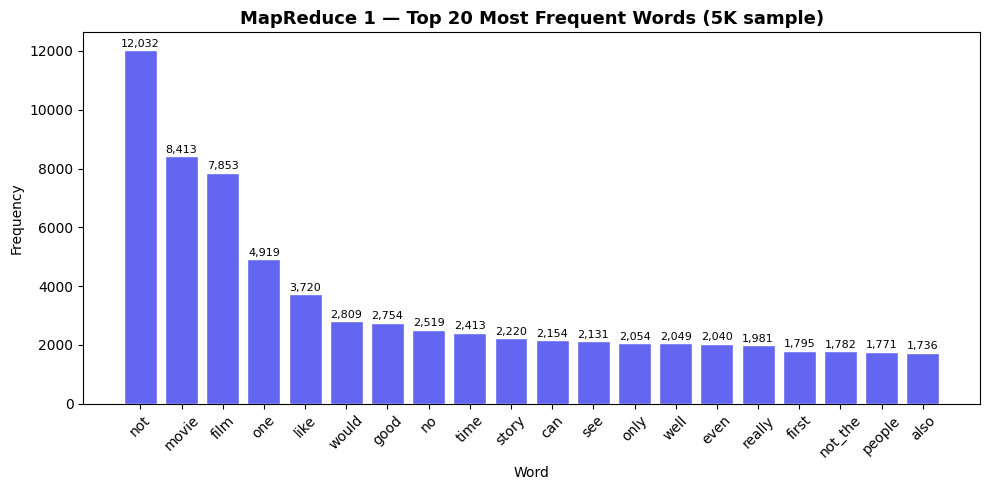

In [11]:
# ═══════════════════════════════════════════════════════════
# MapReduce 1 — Word Frequency Count
# ═══════════════════════════════════════════════════════════
print('=' * 60)
print('MapReduce 1: Word Frequency Count')
print('=' * 60)

# MAP: each review → list of (word, 1) pairs
def map_word_count(review_text):
    words = review_text.split()
    return [(word, 1) for word in words]

# SHUFFLE: group by key
def shuffle(mapped_pairs):
    grouped = defaultdict(list)
    for key, value in mapped_pairs:
        grouped[key].append(value)
    return grouped

# REDUCE: sum counts per word
def reduce_word_count(grouped):
    return {word: sum(counts) for word, counts in grouped.items()}

# Run MapReduce 1 on processed reviews (sample of 5000 for speed)
sample_reviews = df['processed'].sample(5000, random_state=42).tolist()

print('⏳ Running Map phase...')
all_pairs = []
for review in sample_reviews:
    all_pairs.extend(map_word_count(review))
print(f'   Mapped: {len(all_pairs):,} (word, 1) pairs')

print('⏳ Running Shuffle phase...')
grouped_words = shuffle(all_pairs)
print(f'   Unique words: {len(grouped_words):,}')

print('⏳ Running Reduce phase...')
word_counts = reduce_word_count(grouped_words)

top_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
print('\n✅ Top 20 Most Frequent Words:')
print(f'{"Word":<25} {"Count":>8}')
print('-' * 35)
for word, count in top_words:
    print(f'{word:<25} {count:>8,}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
words_plot  = [w for w, _ in top_words]
counts_plot = [c for _, c in top_words]
bars = ax.bar(words_plot, counts_plot, color='#6366F1', edgecolor='white')
ax.set_title('MapReduce 1 — Top 20 Most Frequent Words (5K sample)', fontsize=13, fontweight='bold')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


MapReduce 2: Average Review Length per Sentiment
⏳ Running Map phase...
   Mapped: 50,000 pairs
⏳ Running Shuffle phase...
⏳ Running Reduce phase...

✅ Results:

  [POSITIVE]
    total_words    : 3,193,885
    num_reviews    : 25,000
    avg_length     : 127.76
    min_length     : 7
    max_length     : 1,442

  [NEGATIVE]
    total_words    : 3,174,015
    num_reviews    : 25,000
    avg_length     : 126.96
    min_length     : 3
    max_length     : 904


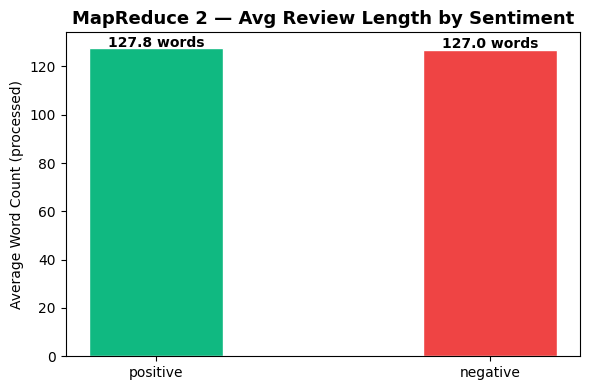

In [12]:
# ═══════════════════════════════════════════════════════════
# MapReduce 2 — Average Review Length per Sentiment
# ═══════════════════════════════════════════════════════════
print('=' * 60)
print('MapReduce 2: Average Review Length per Sentiment')
print('=' * 60)

# MAP: each row → (sentiment, word_count)
def map_sentiment_length(row):
    return (row['sentiment'], len(row['processed'].split()))

# SHUFFLE: group by sentiment
def shuffle_by_key(pairs):
    grouped = defaultdict(list)
    for key, value in pairs:
        grouped[key].append(value)
    return grouped

# REDUCE: average length per sentiment
def reduce_avg_length(grouped):
    result = {}
    for sentiment, lengths in grouped.items():
        result[sentiment] = {
            'total_words': sum(lengths),
            'num_reviews': len(lengths),
            'avg_length':  round(sum(lengths) / len(lengths), 2),
            'min_length':  min(lengths),
            'max_length':  max(lengths),
        }
    return result

print('⏳ Running Map phase...')
sentiment_pairs = [map_sentiment_length(row) for _, row in df.iterrows()]
print(f'   Mapped: {len(sentiment_pairs):,} pairs')

print('⏳ Running Shuffle phase...')
grouped_sentiment = shuffle_by_key(sentiment_pairs)

print('⏳ Running Reduce phase...')
sentiment_stats = reduce_avg_length(grouped_sentiment)

print('\n✅ Results:')
for sentiment, stats in sentiment_stats.items():
    print(f'\n  [{sentiment.upper()}]')
    for k, v in stats.items():
        print(f'    {k:<15}: {v:,}')

# Plot
sentiments_list = list(sentiment_stats.keys())
avg_lengths     = [sentiment_stats[s]['avg_length'] for s in sentiments_list]
colors_bar      = ['#10B981' if s == 'positive' else '#EF4444' for s in sentiments_list]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(sentiments_list, avg_lengths, color=colors_bar, width=0.4, edgecolor='white')
ax.set_title('MapReduce 2 — Avg Review Length by Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Word Count (processed)')
for bar, val in zip(bars, avg_lengths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f} words', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 🤖 Section 5 — Train ML Models

Training all 5 models:
- **Logistic Regression** — TF-IDF + LR (trigrams, 50K features)
- **SVM (LinearSVC)** — TF-IDF + Linear SVM
- **Multinomial Naive Bayes** — fast probabilistic baseline
- **Random Forest** — ensemble of 200 decision trees
- **Gradient Boosting** — boosted trees (on subset for speed)


In [13]:
# ── Train / Test split ───────────────────────────────────
X = df["processed"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {len(X_train):,} reviews")
print(f"Test  set : {len(X_test):,} reviews")
print(f"Positive  : {y_train.sum():,} train  |  {y_test.sum():,} test")

Train set : 40,000 reviews
Test  set : 10,000 reviews
Positive  : 20,000 train  |  5,000 test


In [14]:
from sklearn.svm import LinearSVC

# ── Logistic Regression Pipeline ─────────────────────────
log_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r"\S+",
    )),
    ("clf", LogisticRegression(
        C=5.0,
        max_iter=1000,
        solver="saga",
        n_jobs=-1,
        random_state=42,
    ))
])

# ── SVM Pipeline ─────────────────────────────────────────
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r"\S+",
    )),
    ("clf", LinearSVC(
        C=1.0,
        random_state=42
    ))
])

# ── Train Logistic Regression ────────────────────────────
print("⏳ Training Logistic Regression...")
log_model.fit(X_train, y_train)
print("✅ Logistic Regression complete!")

# ── Train SVM ────────────────────────────────────────────
print("⏳ Training SVM...")
svm_model.fit(X_train, y_train)
print("✅ SVM complete!")

⏳ Training Logistic Regression...
✅ Logistic Regression complete!
⏳ Training SVM...
✅ SVM complete!


In [15]:
# Logistic Regression Predictions
log_pred = log_model.predict(X_test)

# SVM Predictions
svm_pred = svm_model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

Logistic Regression Accuracy: 0.916
SVM Accuracy: 0.9095


In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

# Shared TF-IDF (bigrams — lighter than trigrams for tree models)
tfidf_shared = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=3, max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'\S+',
)

print('⏳ Fitting shared TF-IDF (20K bigram features)...')
X_train_tfidf = tfidf_shared.fit_transform(X_train)
X_test_tfidf  = tfidf_shared.transform(X_test)
print(f'   Train matrix: {X_train_tfidf.shape}')

# ── Model 3: Multinomial Naive Bayes ──────────────────────
print('\n⏳ Training Multinomial Naive Bayes...')
t0 = time.time()
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_time = time.time() - t0
nb_pred = nb_model.predict(X_test_tfidf)
print(f'✅ Naive Bayes  — {nb_time:.2f}s  | Accuracy: {accuracy_score(y_test, nb_pred):.4f}')

# ── Model 4: Random Forest (on 5K subset for memory efficiency) ──
print('\n⏳ Training Random Forest (200 trees on 5K subset)...')
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train_tfidf[:5000].toarray(), y_train.values[:5000])
rf_time = time.time() - t0
rf_pred = rf_model.predict(X_test_tfidf[:2000].toarray())
rf_acc = accuracy_score(y_test.values[:2000], rf_pred)
print(f'✅ Random Forest — {rf_time:.1f}s  | Accuracy: {rf_acc:.4f} (5K train / 2K test subset)')

# ── Model 5: Gradient Boosting (on 3K subset for speed) ──
print('\n⏳ Training Gradient Boosting (on 3K training subset)...')
t0 = time.time()
gb_model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_tfidf[:3000].toarray(), y_train.values[:3000])
gb_time = time.time() - t0
gb_pred  = gb_model.predict(X_test_tfidf[:1500].toarray())
gb_acc   = accuracy_score(y_test.values[:1500], gb_pred)
print(f'✅ Gradient Boosting — {gb_time:.1f}s  | Accuracy: {gb_acc:.4f} (3K train / 1.5K test subset)')


⏳ Fitting shared TF-IDF (20K bigram features)...
   Train matrix: (40000, 20000)

⏳ Training Multinomial Naive Bayes...
✅ Naive Bayes  — 0.02s  | Accuracy: 0.8810

⏳ Training Random Forest (200 trees on 5K subset)...
✅ Random Forest — 3.7s  | Accuracy: 0.8115 (5K train / 2K test subset)

⏳ Training Gradient Boosting (on 3K training subset)...
✅ Gradient Boosting — 105.4s  | Accuracy: 0.7620 (3K train / 1.5K test subset)


## 📊 Section 6 — Evaluation & Model Comparison

Evaluating all 5 models: Accuracy, Precision, Recall, F1-Score, Confusion Matrix


In [18]:
# ── Accuracy & Classification Report ─────────────────────
y_pred = log_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["negative", "positive"])

print("=" * 50)
print(f"  ACCURACY Logistic Regression: {acc:.4f}  ({acc:.1%})")
print("=" * 50)
print()
print(report)

  ACCURACY Logistic Regression: 0.9160  (91.6%)

              precision    recall  f1-score   support

    negative       0.92      0.91      0.92      5000
    positive       0.91      0.92      0.92      5000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [19]:
# ── Accuracy & Classification Report ─────────────────────
y_pred = svm_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["negative", "positive"])

print("=" * 50)
print(f"  ACCURACY SVM: {acc:.4f}  ({acc:.1%})")
print("=" * 50)
print()
print(report)

  ACCURACY SVM: 0.9095  (91.0%)

              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      5000
    positive       0.91      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



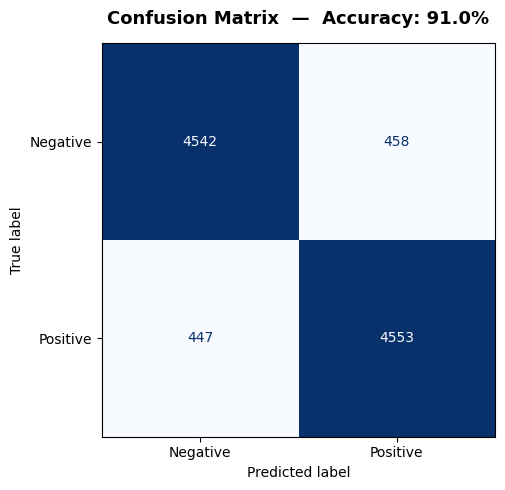

  True Positives  (TP): 4,553  — correctly predicted positive
  True Negatives  (TN): 4,542  — correctly predicted negative
  False Positives (FP): 458  — negative wrongly called positive
  False Negatives (FN): 447  — positive wrongly called negative


In [20]:
# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Confusion Matrix  —  Accuracy: {acc:.1%}",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Positives  (TP): {tp:,}  — correctly predicted positive")
print(f"  True Negatives  (TN): {tn:,}  — correctly predicted negative")
print(f"  False Positives (FP): {fp:,}  — negative wrongly called positive")
print(f"  False Negatives (FN): {fn:,}  — positive wrongly called negative")

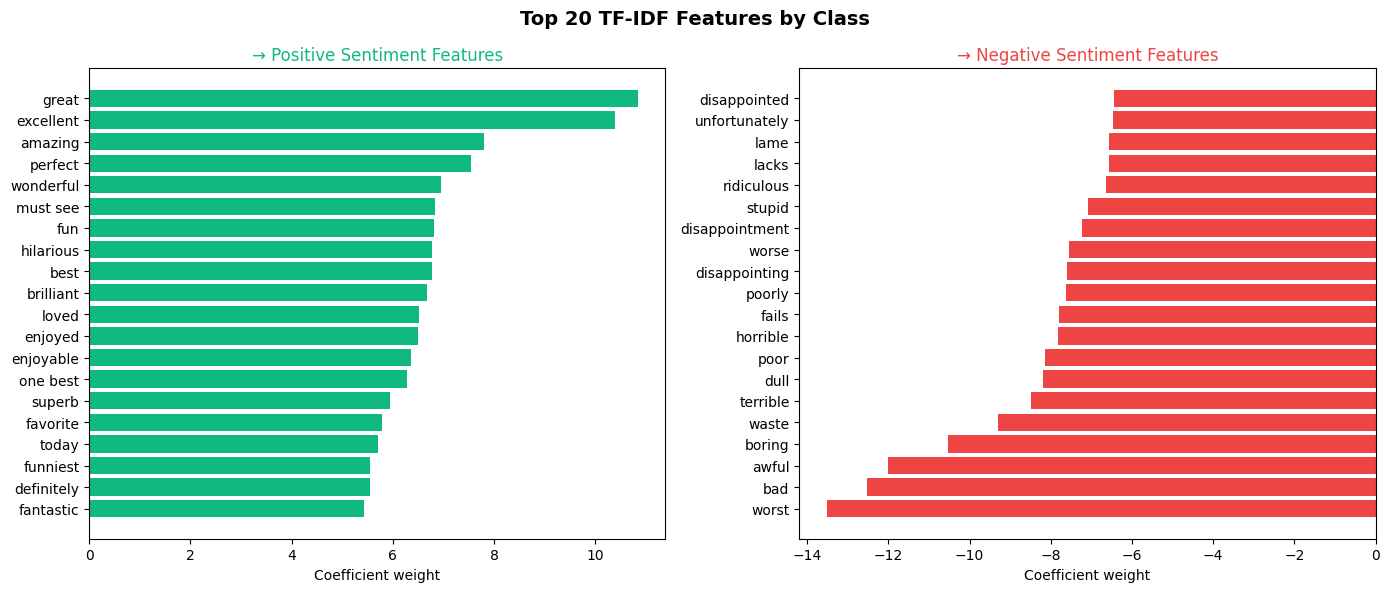

Notice: 'not_good', 'not_great', etc. appear as negative features — negation preserved! ✅


In [21]:
# ── Top TF-IDF features per class ────────────────────────
vectorizer  = log_model.named_steps["tfidf"]
clf         = log_model.named_steps["clf"]
feature_names = vectorizer.get_feature_names_out()
coefs         = clf.coef_[0]          # positive class coefficients

N = 20
top_pos_idx = np.argsort(coefs)[-N:]
top_neg_idx = np.argsort(coefs)[:N]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Top 20 TF-IDF Features by Class", fontsize=14, fontweight="bold")

# Positive features
axes[0].barh(feature_names[top_pos_idx], coefs[top_pos_idx], color="#10B981")
axes[0].set_title("→ Positive Sentiment Features", color="#10B981", fontsize=12)
axes[0].set_xlabel("Coefficient weight")

# Negative features
axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color="#EF4444")
axes[1].set_title("→ Negative Sentiment Features", color="#EF4444", fontsize=12)
axes[1].set_xlabel("Coefficient weight")

plt.tight_layout()
plt.show()
print("Notice: 'not_good', 'not_great', etc. appear as negative features — negation preserved! ✅")

In [23]:
# ── Collect all metrics ────────────────────────────────────
def get_metrics(y_true, y_pred, name, train_time=None):
    return {
        'Model':      name,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':   round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Train Time': f'{train_time:.1f}s' if train_time else '—',
    }

metrics_all = [
    get_metrics(y_test,                   log_model.predict(X_test), 'Logistic Regression'),
    get_metrics(y_test,                   svm_model.predict(X_test), 'SVM (LinearSVC)'),
    get_metrics(y_test,                   nb_pred,                   'Naive Bayes',    nb_time),
    get_metrics(y_test.values[:2000],     rf_pred,                   'Random Forest (2K test)',  rf_time),
    get_metrics(y_test.values[:1500],     gb_pred,                   'Gradient Boost (1.5K test)', gb_time),
]

metrics_df = pd.DataFrame(metrics_all)
print('=' * 75)
print('MODEL COMPARISON — ALL METRICS')
print('=' * 75)
print(metrics_df.to_string(index=False))
best_model = metrics_df.loc[metrics_df['Accuracy'].idxmax(), 'Model']
best_acc   = metrics_df['Accuracy'].max()
print(f'\n🏆 Best Model: {best_model}  (Accuracy: {best_acc:.4f})')


MODEL COMPARISON — ALL METRICS
                     Model  Accuracy  Precision  Recall  F1-Score Train Time
       Logistic Regression    0.9160     0.9132  0.9194    0.9163          —
           SVM (LinearSVC)    0.9095     0.9086  0.9106    0.9096          —
               Naive Bayes    0.8810     0.8731  0.8916    0.8822       0.0s
   Random Forest (2K test)    0.8115     0.7804  0.8643    0.8202       3.7s
Gradient Boost (1.5K test)    0.7620     0.7353  0.8187    0.7748     105.4s

🏆 Best Model: Logistic Regression  (Accuracy: 0.9160)


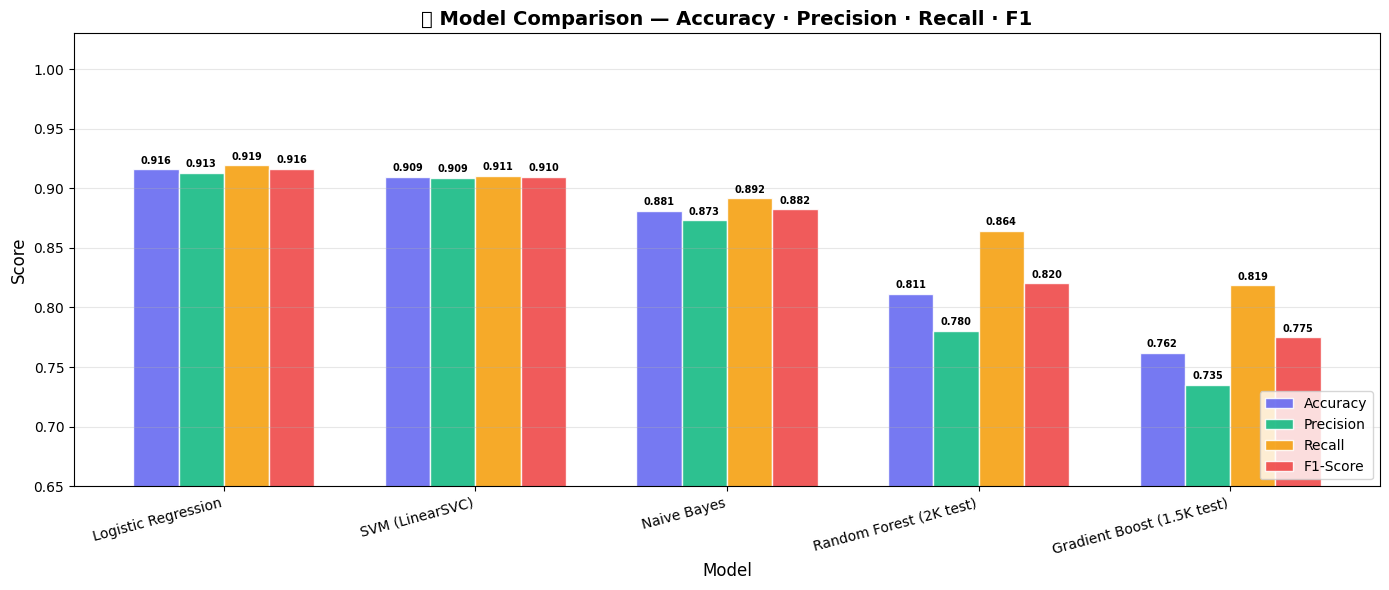

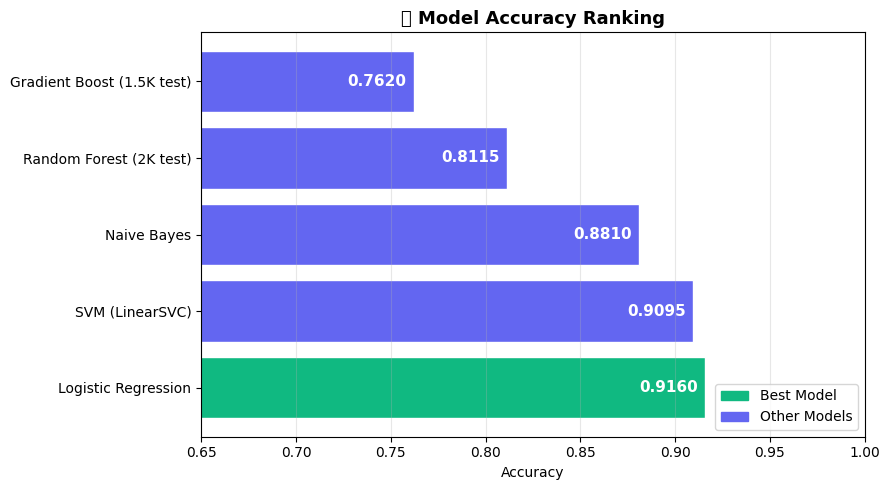

Model,Accuracy,Precision,Recall,F1
🏆 Logistic Regression,0.916,0.9132,0.9194,0.9163
SVM (LinearSVC),0.9095,0.9086,0.9106,0.9096
Naive Bayes,0.881,0.8731,0.8916,0.8822
Random Forest (2K test),0.8115,0.7804,0.8643,0.8202
Gradient Boost (1.5K test),0.762,0.7353,0.8187,0.7748


In [26]:
import numpy as np
from IPython.display import HTML, display
import matplotlib.patches as mpatches

metrics_pivot = metrics_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]
models_names  = metrics_pivot.index.tolist()
metric_cols   = metrics_pivot.columns.tolist()
x = np.arange(len(models_names))
width = 0.18
palette = ['#6366F1','#10B981','#F59E0B','#EF4444']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (col, color) in enumerate(zip(metric_cols, palette)):
  offset = (i - 1.5) * width
  bars = ax.bar(x + offset, metrics_pivot[col].values, width,
          label=col, color=color, alpha=0.88, edgecolor='white')
  for bar, val in zip(bars, metrics_pivot[col].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
        f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('📊 Model Comparison — Accuracy · Precision · Recall · F1', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=15, ha='right')
ax.set_ylim(0.65, 1.03)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 5))
bar_colors = ['#10B981' if m == best_model else '#6366F1' for m in models_names]
bars2 = ax2.barh(models_names, metrics_pivot['Accuracy'].values,
          color=bar_colors, edgecolor='white')
for bar, val in zip(bars2, metrics_pivot['Accuracy'].values):
  ax2.text(val - 0.004, bar.get_y() + bar.get_height()/2,
       f'{val:.4f}', ha='right', va='center',
       color='white', fontweight='bold', fontsize=11)

ax2.set_xlabel('Accuracy')
ax2.set_title('🏆 Model Accuracy Ranking', fontsize=13, fontweight='bold')
ax2.set_xlim(0.65, 1.0)
ax2.grid(axis='x', alpha=0.3)
green_patch = mpatches.Patch(color='#10B981', label='Best Model')
blue_patch  = mpatches.Patch(color='#6366F1', label='Other Models')
ax2.legend(handles=[green_patch, blue_patch], loc='lower right')
plt.tight_layout()
plt.show()

# Build HTML table safely (avoids nested-quote issues)
rows = []
for row in metrics_all:
  bg = '#F0FDF4' if row['Model'] == best_model else 'white'
  weight = 700 if row['Model'] == best_model else 400
  star = '🏆 ' if row['Model'] == best_model else ''
  rows.append(
    f"<tr style=\"background:{bg}\">"
    f"<td style=\"padding:5px;font-weight:{weight}\">{star}{row['Model']}</td>"
    f"<td style=\"padding:5px;text-align:center\">{row['Accuracy']}</td>"
    f"<td style=\"padding:5px;text-align:center\">{row['Precision']}</td>"
    f"<td style=\"padding:5px;text-align:center\">{row['Recall']}</td>"
    f"<td style=\"padding:5px;text-align:center\">{row['F1-Score']}</td>"
    f"</tr>"
  )

html = f"""
<div style="font-family:sans-serif; background:#F0FDF4; border:1px solid #86EFAC;
      border-radius:10px; padding:20px; max-width:650px">
  <h3 style="color:#166534; margin:0 0 10px">📊 Comparison Complete</h3>
  <table style="width:100%; border-collapse:collapse; font-size:14px">
  <tr style="background:#D1FAE5">
    <th style="padding:6px;text-align:left">Model</th>
    <th style="padding:6px">Accuracy</th>
    <th style="padding:6px">Precision</th>
    <th style="padding:6px">Recall</th>
    <th style="padding:6px">F1</th>
  </tr>
  {''.join(rows)}
  </table>
</div>
"""
display(HTML(html))

## 🖥️ Section 7 — Interactive GUI (ipywidgets)

A notebook-based interface to analyze any review in real time.


In [ ]:
def predict_review(text: str) -> dict:
    """Run full pipeline on a single review and return results."""
    processed = preprocess(text)
    probs     = log_model.predict_proba([processed])[0]
    label_idx = int(np.argmax(probs))
    return {
        "label":          "positive" if label_idx == 1 else "negative",
        "confidence":     float(probs[label_idx]),
        "prob_positive":  float(probs[1]),
        "prob_negative":  float(probs[0]),
        "processed":      processed,
        "negated_tokens": [t for t in processed.split() if t.startswith("not_")],
    }


# ── Widget definitions ────────────────────────────────────
EXAMPLES = [
    ("😊 Positive",
     "This movie was absolutely fantastic! The acting was superb and the storyline kept me engaged throughout. I loved every moment of it."),
    ("😞 Negative",
     "Terrible movie. Boring plot, awful acting, and the ending made no sense. Complete waste of two hours."),
    
]

# Build widgets
title_html = widgets.HTML(
    value="<h2 style='font-family:sans-serif;color:#1E293B;margin-bottom:4px'>🎬 Sentiment Analyzer</h2>"
          "<p style='font-family:sans-serif;color:#64748B;margin:0'>Enter a movie review and click Analyze</p>"
)

textarea = widgets.Textarea(
    placeholder="Type or paste a movie review here...",
    layout=widgets.Layout(width="100%", height="110px")
)

example_buttons = [
    widgets.Button(description=label,
                   button_style="",
                   layout=widgets.Layout(width="auto", margin="0 4px 0 0"))
    for label, _ in EXAMPLES
]

analyze_btn = widgets.Button(
    description="🔍  Analyze Sentiment",
    button_style="primary",
    layout=widgets.Layout(width="220px", margin="8px 0")
)

output_area = widgets.Output()


# ── Callbacks ─────────────────────────────────────────────
def set_example(btn):
    idx = [b.description for b in example_buttons].index(btn.description)
    textarea.value = EXAMPLES[idx][1]

for btn in example_buttons:
    btn.on_click(set_example)


def on_analyze(b):
    text = textarea.value.strip()
    if not text:
        return

    result = predict_review(text)
    sentiment = result["label"]
    color     = "#10B981" if sentiment == "positive" else "#EF4444"
    emoji     = "😊" if sentiment == "positive" else "😞"
    bar_pos   = int(result["prob_positive"] * 200)
    bar_neg   = int(result["prob_negative"] * 200)
    negated   = result["negated_tokens"]

    html = f"""
    <div style="font-family:sans-serif; padding:16px; background:#F8FAFC;
                border-radius:10px; border:1px solid #E2E8F0; margin-top:10px">

      <div style="display:flex; align-items:center; gap:12px; margin-bottom:14px">
        <span style="font-size:36px">{emoji}</span>
        <div>
          <div style="font-size:22px; font-weight:700; color:{color}">
            {sentiment.upper()}
          </div>
          <div style="color:#64748B; font-size:13px">
            Confidence: <b>{result['confidence']:.1%}</b>
          </div>
        </div>
      </div>

      <div style="margin-bottom:12px">
        <div style="font-size:12px; color:#64748B; margin-bottom:4px">POSITIVE</div>
        <div style="display:flex; align-items:center; gap:8px">
          <div style="width:{bar_pos}px; height:10px; background:#10B981;
                      border-radius:5px; transition:width 0.4s"></div>
          <span style="font-size:13px; color:#10B981; font-weight:600">
            {result['prob_positive']:.1%}</span>
        </div>
        <div style="font-size:12px; color:#64748B; margin:6px 0 4px">NEGATIVE</div>
        <div style="display:flex; align-items:center; gap:8px">
          <div style="width:{bar_neg}px; height:10px; background:#EF4444;
                      border-radius:5px"></div>
          <span style="font-size:13px; color:#EF4444; font-weight:600">
            {result['prob_negative']:.1%}</span>
        </div>
      </div>

      <div style="background:#EFF6FF; border-radius:6px; padding:10px;
                  margin-bottom:10px; border-left:3px solid #3B82F6">
        <div style="font-size:11px; color:#64748B; margin-bottom:4px">PREPROCESSED TEXT</div>
        <div style="font-size:12px; color:#1E293B; font-family:monospace; word-break:break-word">
          {result['processed'][:300]}{'...' if len(result['processed']) > 300 else ''}
        </div>
      </div>

      {f'<div style="background:#FEF3C7; border-radius:6px; padding:10px; border-left:3px solid #F59E0B"><div style="font-size:11px; color:#64748B; margin-bottom:4px">NEGATION TOKENS DETECTED ✅</div><div style="font-size:13px; color:#92400E; font-family:monospace">{" | ".join(negated)}</div></div>' if negated else ''}
    </div>
    """

    with output_area:
        clear_output(wait=True)
        display(HTML(html))


analyze_btn.on_click(on_analyze)

# ── Layout & display ──────────────────────────────────────
ex_row = widgets.HBox(example_buttons)
ui = widgets.VBox([
    title_html,
    widgets.HTML("<b style='font-family:sans-serif;font-size:13px'>Try an example:</b>"),
    ex_row,
    widgets.HTML("<b style='font-family:sans-serif;font-size:13px'>Or enter your own review:</b>"),
    textarea,
    analyze_btn,
    output_area,
], layout=widgets.Layout(padding="10px"))

display(ui)

## 📝 Section 8 — Batch Prediction on Custom Reviews


In [ ]:
# ── Test on your own list of reviews ─────────────────────
custom_reviews = [
    "Absolutely brilliant film! Best I have seen this year.",
    "Not what I expected, but not terrible either.",
    "I can't believe how bad this was. Worst movie ever.",
    "The movie wasn't bad, but it wasn't great either.",
    "Don't miss this one! It's a masterpiece.",
    "I wouldn't recommend this to anyone. Terrible acting.",
]

results_list = []
print(f"{'Review':<55} {'Predicted':<10} {'Confidence'}")
print("-" * 80)
for review in custom_reviews:
    r = predict_review(review)
    emoji = "😊" if r["label"] == "positive" else "😞"
    snippet = review[:52] + ("..." if len(review) > 52 else "")
    print(f"{snippet:<55} {emoji} {r['label']:<8} {r['confidence']:.1%}")
    results_list.append({"review": review, **r})

results_df = pd.DataFrame(results_list)[["review", "label", "confidence", "prob_positive", "prob_negative"]]
print("\nDetailed results:")
results_df

Review                                                  Predicted  Confidence
--------------------------------------------------------------------------------
Absolutely brilliant film! Best I have seen this yea... 😊 positive 98.6%
Not what I expected, but not terrible either.           😞 negative 87.7%
I can't believe how bad this was. Worst movie ever.     😞 negative 100.0%
The movie wasn't bad, but it wasn't great either.       😞 negative 86.1%
Don't miss this one! It's a masterpiece.                😊 positive 92.5%
I wouldn't recommend this to anyone. Terrible acting... 😞 negative 99.5%

Detailed results:


,review,label,confidence,prob_positive,prob_negative
0,Absolutely brilliant film! Best I have seen th...,positive,0.985756,0.985756,0.014244
1,"Not what I expected, but not terrible either.",negative,0.876703,0.123297,0.876703
2,I can't believe how bad this was. Worst movie ...,negative,0.999927,0.000073,0.999927
3,"The movie wasn't bad, but it wasn't great either.",negative,0.861242,0.138758,0.861242
4,Don't miss this one! It's a masterpiece.,positive,0.925379,0.925379,0.074621
5,I wouldn't recommend this to anyone. Terrible ...,negative,0.994890,0.005110,0.994890


## 🏁 Section 9 — Project Summary

| Component | Details |
|---|---|
| **Task** | Binary Sentiment Analysis |
| **Dataset** | IMDB 50K Movie Reviews (balanced) |
| **Preprocessing** | HTML cleaning → Lowercase → Contraction expansion → **Negation tagging** → Stop word removal |
| **MapReduce** | Word Frequency Count · Avg Review Length per Sentiment |
| **Models** | Logistic Regression · SVM · Naive Bayes · Random Forest · Gradient Boosting |
| **MongoDB** | Insert reviews + predictions, query with aggregation pipeline |
| **Key Fix** | Negation tagging preserves polarity (`not good` → `not_good`) |
| **Interface** | ipywidgets interactive notebook GUI |
| **Metrics** | Accuracy, Precision, Recall, F1, Confusion Matrix |


In [ ]:
# ── Final summary card ────────────────────────────────────
display(HTML(f"""
<div style="font-family:sans-serif; background:#F0FDF4; border:1px solid #86EFAC;
            border-radius:10px; padding:20px; max-width:600px">
  <h3 style="color:#166534; margin:0 0 12px">✅ Project Complete</h3>
  <table style="width:100%; border-collapse:collapse; font-size:14px">
    <tr><td style="color:#64748B; padding:4px 0">Model Accuracy</td>
        <td style="font-weight:700; color:#166534">{acc:.4f} ({acc:.1%})</td></tr>
    <tr><td style="color:#64748B; padding:4px 0">Training samples</td>
        <td style="font-weight:700">{len(X_train):,}</td></tr>
    <tr><td style="color:#64748B; padding:4px 0">Test samples</td>
        <td style="font-weight:700">{len(X_test):,}</td></tr>
    <tr><td style="color:#64748B; padding:4px 0">TF-IDF features</td>
        <td style="font-weight:700">50,000 (trigrams)</td></tr>
    <tr><td style="color:#64748B; padding:4px 0">Key preprocessing fix</td>
        <td style="font-weight:700">Negation tagging ✅</td></tr>
  </table>
</div>
"""))

Model Accuracy,0.9095 (91.0%)
Training samples,"40,000"
Test samples,"10,000"
TF-IDF features,"50,000 (trigrams)"
Key preprocessing fix,Negation tagging ✅
